In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = "../dataset/Sales - Marketing customer dataset.csv"
data = pd.read_csv(path)

data.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


#Soal Ketiga : Modeling Dengan Preprocessing

###Duplikat

In [2]:
duplicate_count = data.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


##Missing value

In [3]:
# Missing values (%)
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

print(missing_data)

                            Missing Count  Missing %
coupon_code                          6133  40.886667
age                                  1200   8.000000
total_spent                          1050   7.000000
gender                                738   4.920000
satisfaction_score                    702   4.680000
customer_id                             0   0.000000
last_3_month_purchase_freq              0   0.000000
lifetime_value                          0   0.000000
marketing_spend_per_user                0   0.000000
nps_score                               0   0.000000
payment_method                          0   0.000000
delivery_delay_days                     0   0.000000
refund_requested                        0   0.000000
support_tickets                         0   0.000000
discount_used                           0   0.000000
avg_order_value                         0   0.000000
email_click_rate                        0   0.000000
email_open_rate                         0   0.

In [4]:
data['coupon_code'] = data['coupon_code'].fillna('No_Coupon')
data['gender'] = data['gender'].fillna('Other')

median_satisfaction_score = data['satisfaction_score'].median()
data['satisfaction_score'] = data['satisfaction_score'].fillna(median_satisfaction_score)

mean_age = data['age'].mean()
data['age'] = data['age'].fillna(mean_age)

median_total_spent = data['total_spent'].median()
data['total_spent'] = data['total_spent'].fillna(median_total_spent)

In [5]:
# Missing values (%)
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

print(missing_data)

                            Missing Count  Missing %
customer_id                             0        0.0
gender                                  0        0.0
last_3_month_purchase_freq              0        0.0
lifetime_value                          0        0.0
marketing_spend_per_user                0        0.0
nps_score                               0        0.0
satisfaction_score                      0        0.0
payment_method                          0        0.0
delivery_delay_days                     0        0.0
refund_requested                        0        0.0
support_tickets                         0        0.0
coupon_code                             0        0.0
discount_used                           0        0.0
avg_order_value                         0        0.0
total_spent                             0        0.0
email_click_rate                        0        0.0
email_open_rate                         0        0.0
pages_per_session                       0     

##Outlier

Berdasarkan EDA

*   Fitur Kategori sudah bersih kecuali fitur tanggal yang perlu melakukan penanganan
*   Fitur ordinal juga sudah konsisten 1-5 dan 0-10
*   Fitur numerik juga sudah tidak ada anomali
*   Fitur target juga hanya 2 nilai unik
Jdi kita bisa langsung menengecek di fitur numerik kecuali id






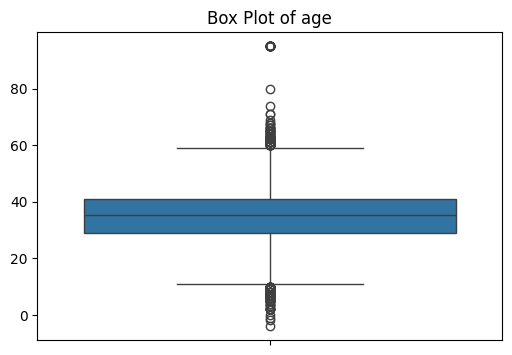

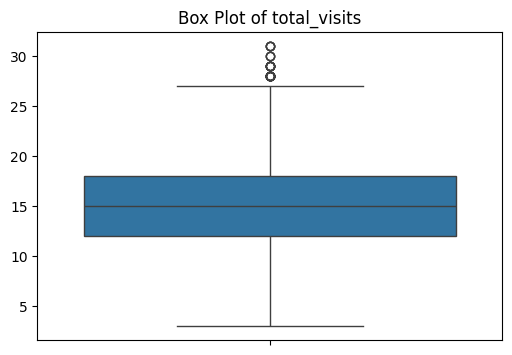

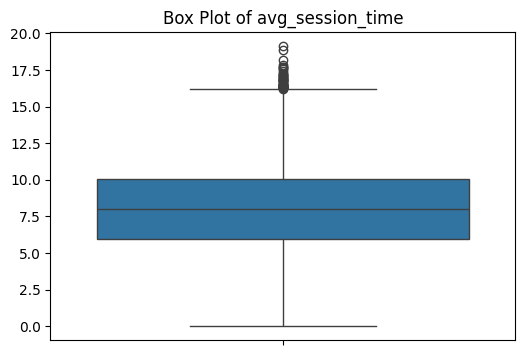

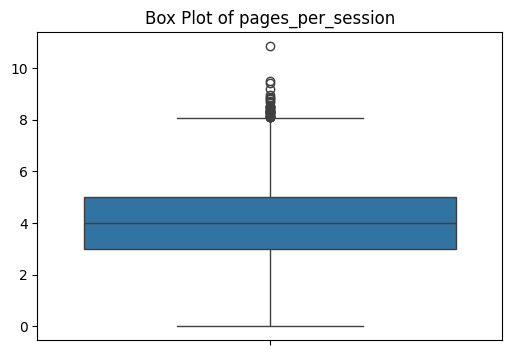

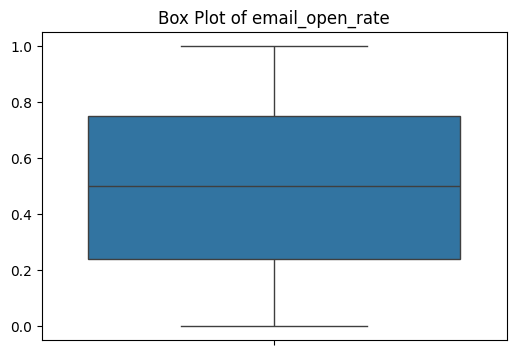

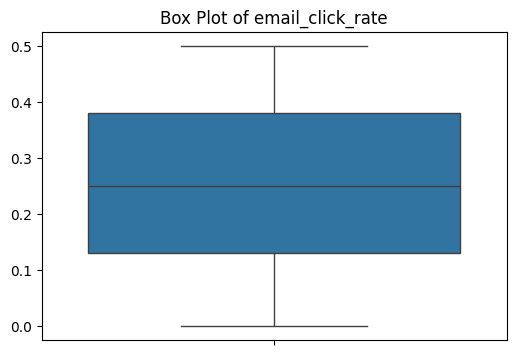

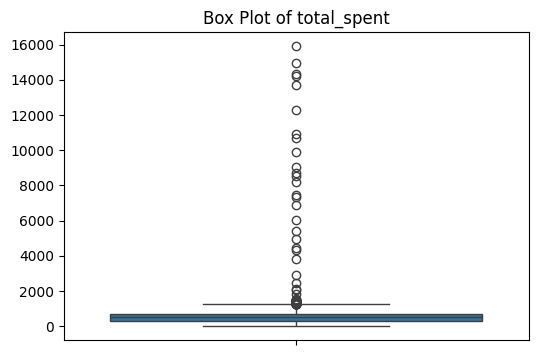

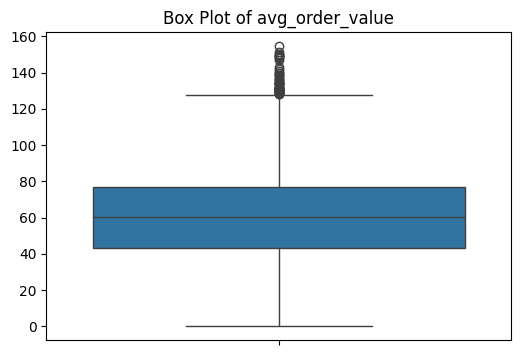

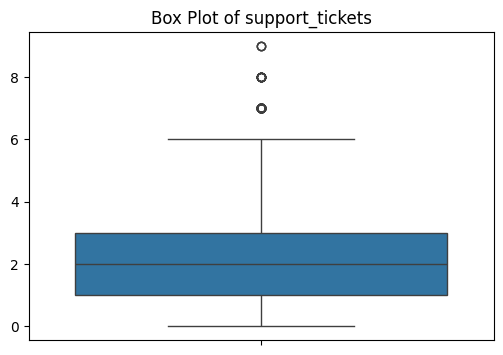

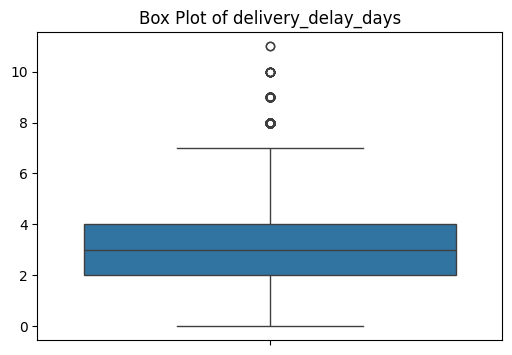

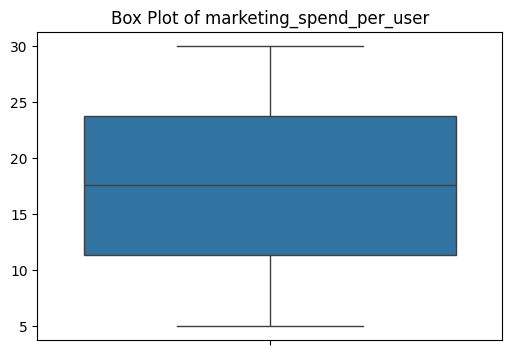

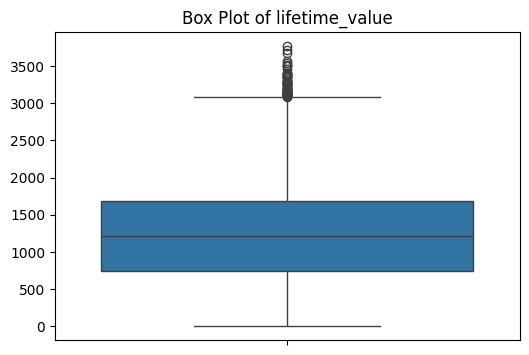

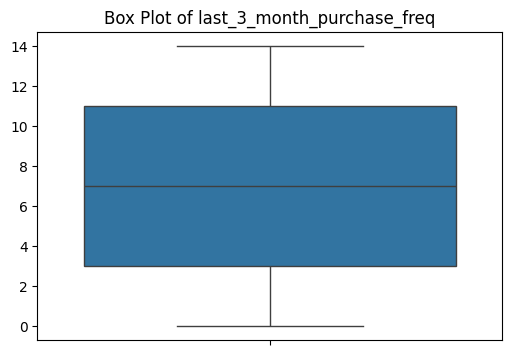

In [6]:
numerical_features = [
    'age',
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'email_open_rate',
    'email_click_rate',
    'total_spent',
    'avg_order_value',
    'support_tickets',
    'delivery_delay_days',
    'marketing_spend_per_user',
    'lifetime_value',
    'last_3_month_purchase_freq'
]

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
    plt.show()

In [7]:
data[numerical_features].describe()

,age,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,support_tickets,delivery_delay_days,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,35.203913,15.000933,8.020805,4.002901,0.496278,0.251231,522.571450,60.080882,1.995600,2.981333,17.575238,1235.698200,6.975133
std,9.912364,3.892704,2.991499,1.479846,0.290108,0.144689,450.452690,24.746203,1.421214,1.720537,7.183437,657.521849,4.323443
min,-4.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,5.000000,0.368886,0.000000
25%,29.000000,12.000000,5.974555,2.989150,0.240000,0.130000,317.255562,43.032470,1.000000,2.000000,11.380000,741.301251,3.000000
50%,35.203913,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,2.000000,3.000000,17.630000,1216.210685,7.000000
75%,41.000000,18.000000,10.059986,5.014406,0.750000,0.380000,683.781508,76.888445,3.000000,4.000000,23.770000,1677.860399,11.000000
max,95.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,9.000000,11.000000,30.000000,3767.490455,14.000000


In [8]:
print("### Outlier Analysis ###\n")

for col in numerical_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_percentage = (outlier_count / len(data)) * 100

    print(f"Feature: {col}")
    print(f"  Number of outliers: {outlier_count}")
    print(f"  Percentage of outliers: {outlier_percentage:.2f}%\n")

### Outlier Analysis ###

Feature: age
  Number of outliers: 218
  Percentage of outliers: 1.45%

Feature: total_visits
  Number of outliers: 39
  Percentage of outliers: 0.26%

Feature: avg_session_time
  Number of outliers: 45
  Percentage of outliers: 0.30%

Feature: pages_per_session
  Number of outliers: 33
  Percentage of outliers: 0.22%

Feature: email_open_rate
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: email_click_rate
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: total_spent
  Number of outliers: 119
  Percentage of outliers: 0.79%

Feature: avg_order_value
  Number of outliers: 54
  Percentage of outliers: 0.36%

Feature: support_tickets
  Number of outliers: 79
  Percentage of outliers: 0.53%

Feature: delivery_delay_days
  Number of outliers: 184
  Percentage of outliers: 1.23%

Feature: marketing_spend_per_user
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: lifetime_value
  Number of outliers: 56
  Percentage o

###Age

In [9]:
import numpy as np
data = data[(data['age'] >= 0) | (data['age'].isna())]

##Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

categorical_features_to_encode = [
    'gender', 'country', 'city', 'acquisition_channel',
    'device_type', 'subscription_type', 'coupon_code', 'payment_method'
]

le = LabelEncoder()
for col in categorical_features_to_encode:
    data[col] = le.fit_transform(data[col].astype(str))

##Feature Engineering 4 datetime

In [11]:
# FEATURE ENGINEERING UNTUK KOLOM TANGGAL
data['signup_date'] = pd.to_datetime(data['signup_date'])
data['last_purchase_date'] = pd.to_datetime(data['last_purchase_date'])

data['days_to_last_purchase'] = (data['last_purchase_date'] - data['signup_date']).dt.days

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month

data = data.drop(columns=['signup_date', 'last_purchase_date'])

print(data[['days_to_last_purchase', 'signup_year', 'signup_month']].head())

   days_to_last_purchase  signup_year  signup_month
0                    966         2022             5
1                    -40         2024             6
2                    249         2023             8
3                   -253         2024             1
4                    261         2023             7


In [12]:
data.head()

,customer_id,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,...,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,days_to_last_purchase,signup_year,signup_month
0,10001,1,52.0,2,0,0,2,0,1,7,...,4,3.0,10,27.56,915.310827,14,0,966,2022,5
1,10002,2,35.0,1,5,3,0,1,0,19,...,0,3.0,7,15.15,2079.960938,11,0,-40,2024,6
2,10003,0,27.0,1,4,0,1,0,1,18,...,4,5.0,6,13.51,1379.150885,9,0,249,2023,8
3,10004,0,36.0,2,5,1,2,0,1,16,...,2,4.0,6,25.65,774.652684,7,0,-253,2024,1
4,10005,1,29.0,4,3,4,1,1,0,12,...,0,3.0,1,12.39,87.680409,11,0,261,2023,7


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14997 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 14997 non-null  int64  
 1   gender                      14997 non-null  int32  
 2   age                         14997 non-null  float64
 3   country                     14997 non-null  int32  
 4   city                        14997 non-null  int32  
 5   acquisition_channel         14997 non-null  int32  
 6   device_type                 14997 non-null  int32  
 7   subscription_type           14997 non-null  int32  
 8   is_premium_user             14997 non-null  int64  
 9   total_visits                14997 non-null  int64  
 10  avg_session_time            14997 non-null  float64
 11  pages_per_session           14997 non-null  float64
 12  email_open_rate             14997 non-null  float64
 13  email_click_rate            14997 no

##Drop Id

In [14]:
data = data.drop(columns=['customer_id'])

##Korelasi Matrix

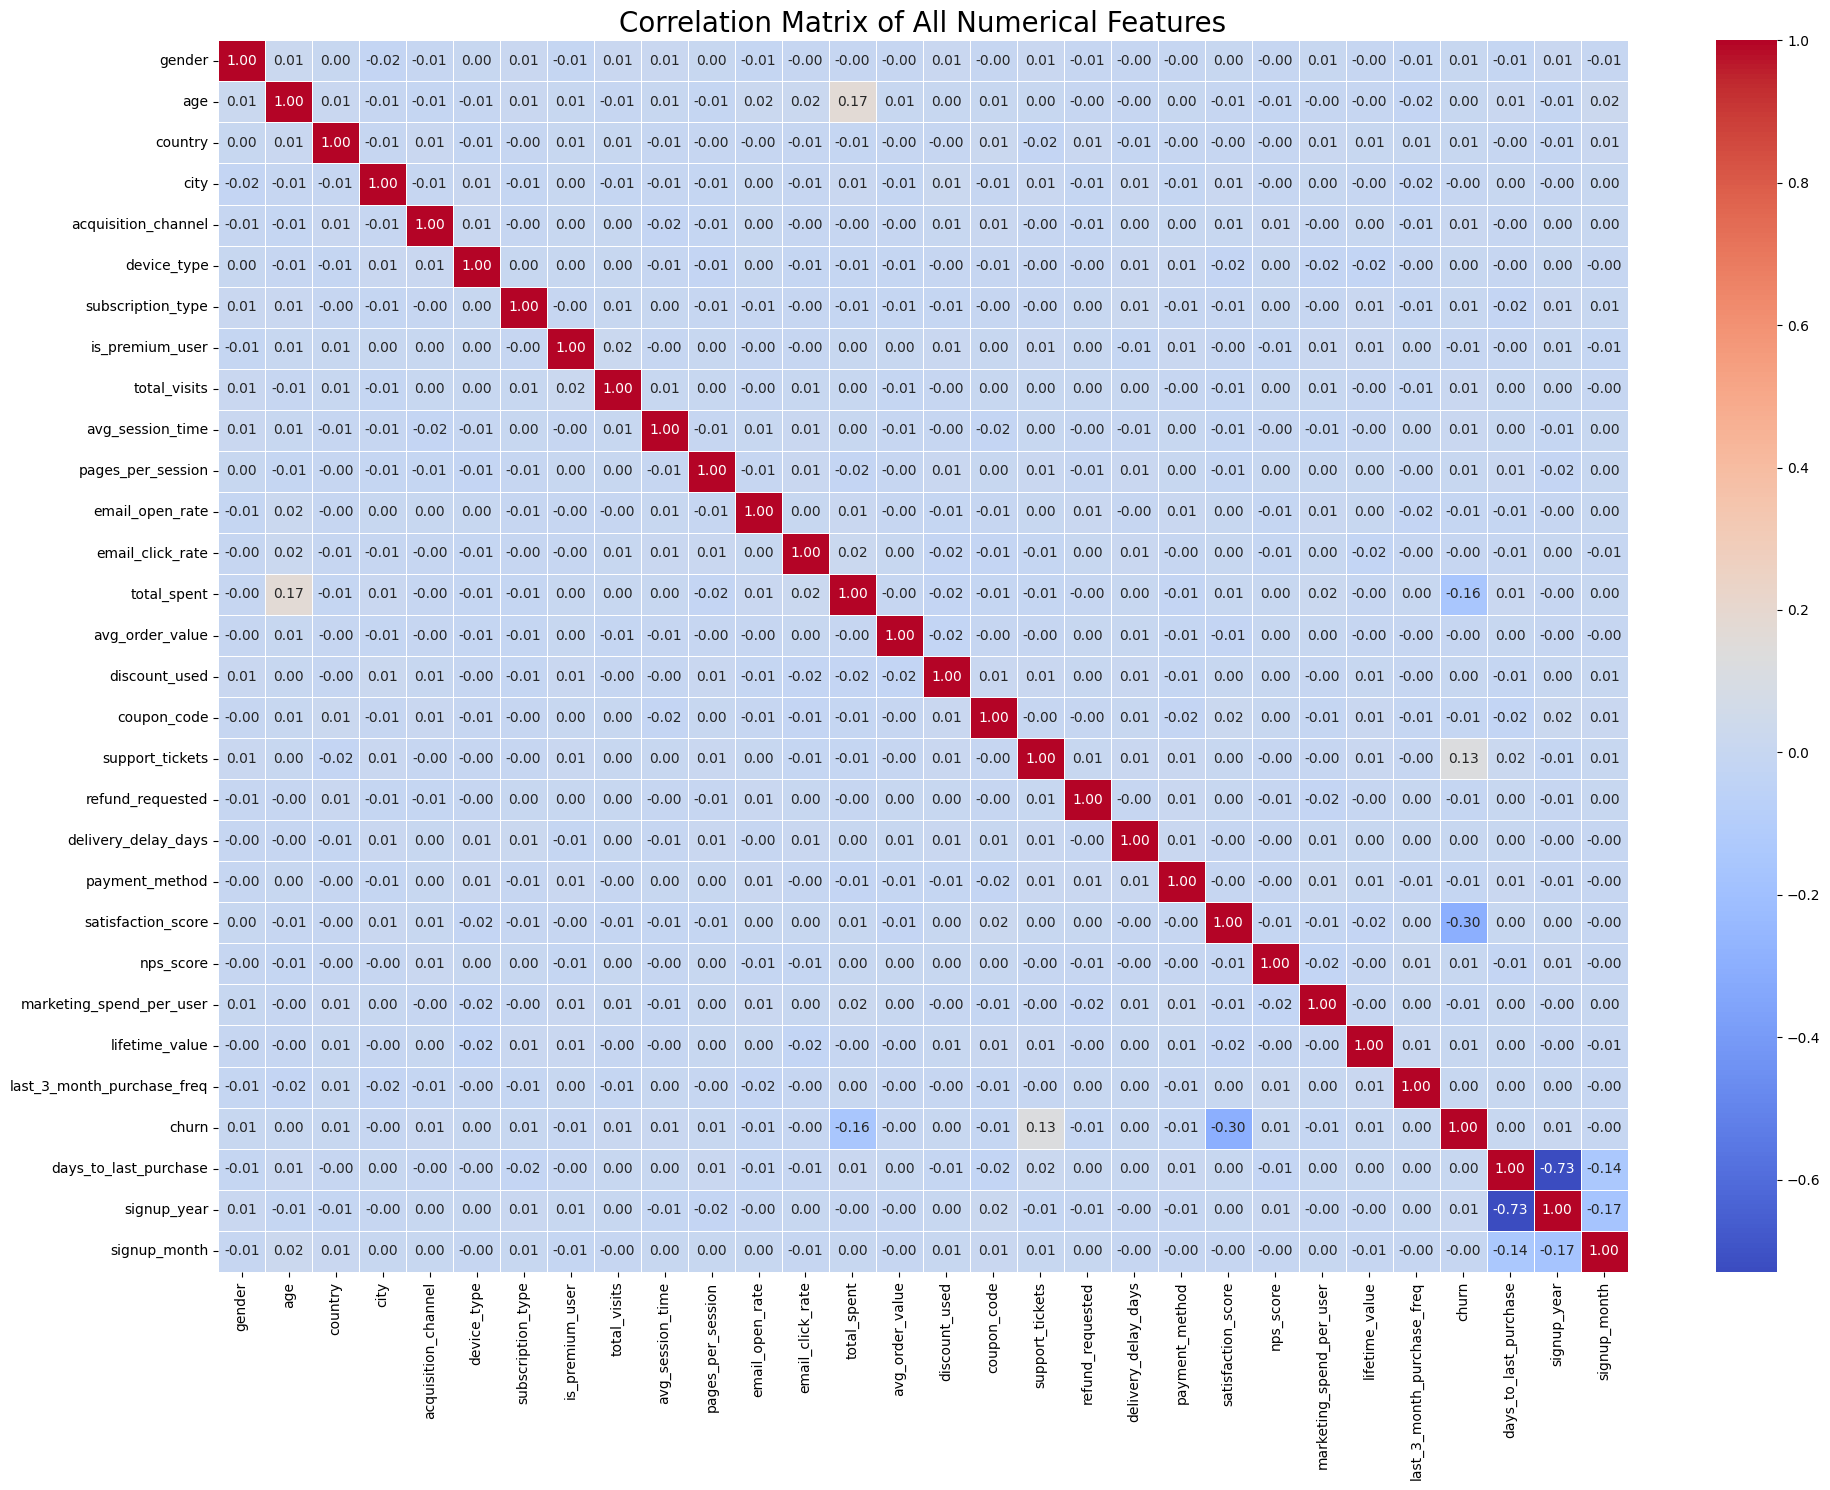

In [15]:
correlation_matrix_all = data.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##Declare x,y dan Split

In [16]:
X = data.drop(columns=['churn'])
y = data['churn']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape X_train (Ori):", X_train.shape)
print("Shape X_test (Ori) :", X_test.shape)

Shape X_train (Ori): (11997, 29)
Shape X_test (Ori) : (3000, 29)


##Penanganan Imbalance

In [18]:
from imblearn.combine import SMOTETomek
from collections import Counter

print("Original class distribution in y_train:", Counter(y_train))

smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train, y_train)
print("Class distribution after SMOTE-Tomek:", Counter(y_train_resampled))

Original class distribution in y_train: Counter({0: 10174, 1: 1823})
Class distribution after SMOTE-Tomek: Counter({0: 9904, 1: 9904})


##Standarisasi

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)
y_train_final = y_train_resampled

print("Data Train Siap (X_train_scaled) Shape:", X_train_scaled.shape)
print("Data Test Siap  (X_test_scaled)  Shape:", X_test_scaled.shape)

Data Train Siap (X_train_scaled) Shape: (19808, 29)
Data Test Siap  (X_test_scaled)  Shape: (3000, 29)


Data test wajib ikut di-scaling karena model machine learning (seperti Logistic Regression atau SVM) mempelajari pola hubungan antarfitur berdasarkan rentang nilai atau skala baru yang dibentuk oleh data train. Jika data test dibiarkan menggunakan angka aslinya yang besar sementara model mengekspektasikan input angka yang sudah diperkecil, prediksi model akan kacau akibat perbedaan bobot matematis tersebut. Proses ini tetap aman dari data leakage (kebocoran data) asalkan kita hanya menggunakan fungsi .transform() pada data test, yang artinya kita hanya mengubah format satu arah menggunakan parameter skala (rata-rata dan varians) milik data train tanpa membiarkan data test ikut memengaruhi atau mengubah rumus skala itu sendiri.

##Modeling

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


=== Logistic Regression Evaluation ===

-- Accuracy --
Train: 0.8200
Test : 0.7690

-- F1 Score (Macro) --
Train: 0.8199
Test : 0.6397

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      9904
           1       0.81      0.83      0.82      9904

    accuracy                           0.82     19808
   macro avg       0.82      0.82      0.82     19808
weighted avg       0.82      0.82      0.82     19808


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.90      0.81      0.86      2526
           1       0.35      0.54      0.42       474

    accuracy                           0.77      3000
   macro avg       0.63      0.68      0.64      3000
weighted avg       0.82      0.77      0.79      3000



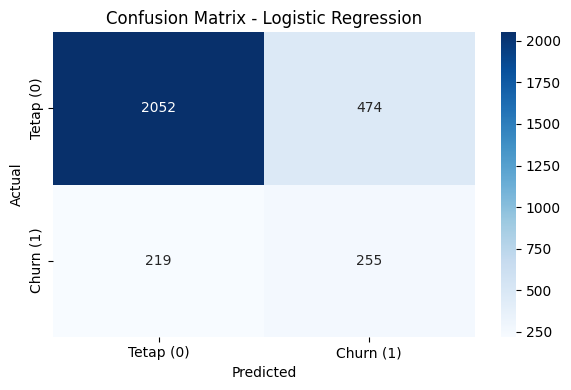

In [21]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train
lr_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("=== Logistic Regression Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_lr):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_lr):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_lr, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_lr, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_lr))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_lr))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Pembersihan data dan penyeimbangan kelas berhasil menyelamatkan model ini dari masalah gagal konvergensi (convergence warning), yang ditandai dengan lonjakan tajam pada Recall Kelas 1 dari 17% menjadi 54%. Meskipun akurasi globalnya sedikit turun karena model tidak lagi menebak Kelas 0 secara membabi buta, nilai Macro F1-Score naik signifikan dari 0.58 menjadi 0.64, membuktikan bahwa model sekarang jauh lebih adil dan realistis dalam memprediksi kedua kelas.

=== Random Forest Evaluation ===

-- Accuracy --
Train: 1.0000
Test : 0.8393

-- F1 Score (Macro) --
Train: 1.0000
Test : 0.7332

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9904
           1       1.00      1.00      1.00      9904

    accuracy                           1.00     19808
   macro avg       1.00      1.00      1.00     19808
weighted avg       1.00      1.00      1.00     19808


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2526
           1       0.49      0.66      0.56       474

    accuracy                           0.84      3000
   macro avg       0.71      0.77      0.73      3000
weighted avg       0.86      0.84      0.85      3000



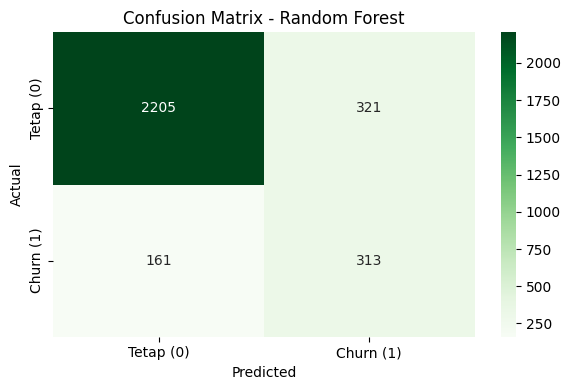

In [22]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=1000)

# Train
rf_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
print("=== Random Forest Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_rf):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_rf):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_rf, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_rf, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_rf))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Langkah pre-processing berhasil mendongkrak sensitivitas model ini secara luar biasa, di mana Recall Kelas 1 melejit dari yang semula hanya 12% menjadi 66%, menjadikannya model terbaik dalam menangkap target Kelas 1. Kendati demikian, model ini masih mengidap masalah overfitting yang sangat kentara karena performanya di data Train tetap sempurna (1.00) sementara performa data Test-nya tertinggal di angka 0.84.

=== Ensemble Voting Evaluation ===

-- Accuracy --
Train: 0.9965
Test : 0.8417

-- F1 Score (Macro) --
Train: 0.9965
Test : 0.7227

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9904
           1       0.99      1.00      1.00      9904

    accuracy                           1.00     19808
   macro avg       1.00      1.00      1.00     19808
weighted avg       1.00      1.00      1.00     19808


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2526
           1       0.50      0.59      0.54       474

    accuracy                           0.84      3000
   macro avg       0.71      0.74      0.72      3000
weighted avg       0.85      0.84      0.85      3000



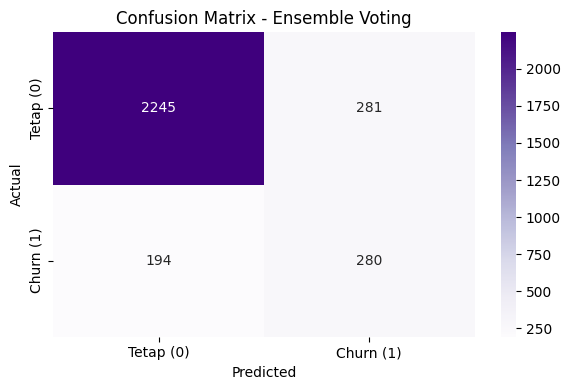

In [23]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
rf_base = RandomForestClassifier(random_state=42, n_estimators=1000)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    voting='soft'
)

# Train
voting_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_vt = voting_model.predict(X_train_scaled)
y_test_pred_vt = voting_model.predict(X_test_scaled)

# Evaluation
print("=== Ensemble Voting Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_vt):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_vt):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_vt, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_vt, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_vt))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_vt))

cm_vt = confusion_matrix(y_test, y_test_pred_vt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_vt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Ensemble Voting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Sebagai penggabung kekuatan, model ini menunjukkan peningkatan performa yang paling seimbang dan stabil dengan kenaikan Macro F1-Score mencapai 0.72 dan kemampuan deteksi Kelas 1 (Recall) yang melonjak hingga 59%. Model ini berhasil mempertahankan akurasi global yang tinggi (84%) sekaligus menekan eror salah tebak, menjadikannya pilihan yang paling aman dan konsisten untuk digunakan dibandingkan saat direct modeling.

In [27]:
summary_data_after = {
    'Model': ['Logistic Regression', 'Random Forest', 'Ensemble Voting'],
    'Accuracy': [0.7690, 0.8393, 0.8417],
    'F1-Score (Macro)': [0.6397, 0.7332, 0.7227],
    'Precision (Churn/1)': [0.3500, 0.4900, 0.5000], 
    'Recall (Churn/1)': [0.5400, 0.6600, 0.5900]
}

data_summary_after = pd.DataFrame(summary_data_after)
print(data_summary_after.to_string(index=False))

              Model  Accuracy  F1-Score (Macro)  Precision (Churn/1)  Recall (Churn/1)
Logistic Regression    0.7690            0.6397                 0.35              0.54
      Random Forest    0.8393            0.7332                 0.49              0.66
    Ensemble Voting    0.8417            0.7227                 0.50              0.59


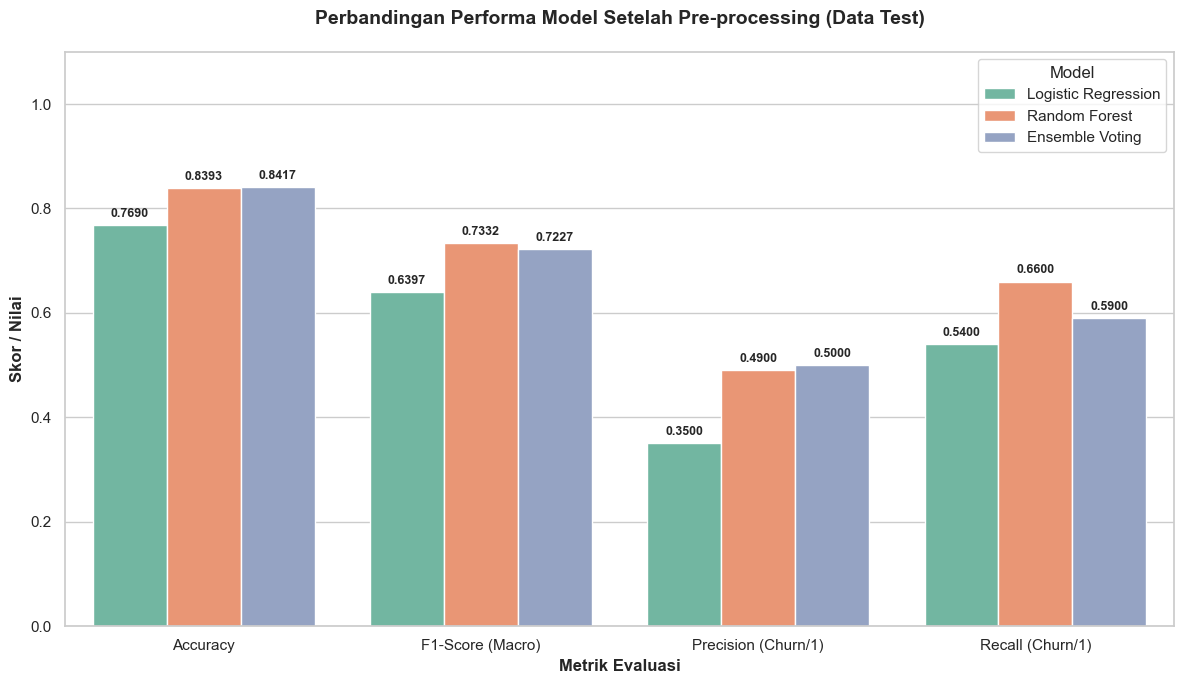

In [28]:

data_melted = pd.melt(
    data_summary_after, id_vars="Model", var_name="Metrik", value_name="Skor"
)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="Metrik", y="Skor", hue="Model", data=data_melted, palette="Set2"
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

plt.title(
    "Perbandingan Performa Model Setelah Pre-processing (Data Test)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.ylabel("Skor / Nilai", fontsize=12, fontweight="bold")
plt.xlabel("Metrik Evaluasi", fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)  
plt.legend(title="Model", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Berdasarkan hasil pengujian skenario After Pre-processing, intervensi penyeimbangan kelas (oversampling) pada data latihan berhasil membongkar ilusi akurasi yang sebelumnya mendominasi. Meskipun tingkat akurasi pengujian (Test Accuracy) mengalami penurunan yang wajar ke kisaran 76% – 84% karena model tidak lagi menebak kelas mayoritas secara bias, kemampuan ketiga model dalam mendeteksi kelas target (1 / Churn) justru melonjak drastis. Perubahan paling radikal terjadi pada model Random Forest yang kini keluar sebagai model terbaik dalam menangkap sinyal churn dengan capaian nilai Recall test tertinggi sebesar 0.6600 dan F1-Score Macro 0.7332, walaupun model ini masih menunjukkan indikasi overfitting karena performa data latihan yang tetap sempurna (1.0000).

Di sisi lain, model Logistic Regression berhasil terbebas dari masalah gagal konvergensi (convergence warning) berkat proses scaling data, menghasilkan peningkatan sensitivitas Recall test yang signifikan menjadi 0.5400 meskipun harus mengorbankan akurasi globalnya ke angka 0.7690. Sementara itu, Ensemble Voting tetap menunjukkan performa yang sangat solid dan seimbang di seluruh metrik pengujian dengan mencatat akurasi tertinggi sebesar 0.8417, nilai Precision target paling kompetitif (0.5000), serta tingkat pengenalan churn (Recall) yang kuat di angka 0.5900, menjadikannya model yang paling konsisten dan minim risiko salah tebak.

#Soal Ke-empat : Hyperparameter Tuning dan Feature Selection

##Feature Important

Feature Importances from Logistic Regression:
                       Feature  Importance
13                 total_spent    1.738480
21          satisfaction_score    1.225371
27                 signup_year    0.514228
26       days_to_last_purchase    0.424898
7              is_premium_user    0.404240
18            refund_requested    0.351668
0                       gender    0.348606
17             support_tickets    0.343545
6            subscription_type    0.334603
5                  device_type    0.330480
15               discount_used    0.308774
16                 coupon_code    0.307090
20              payment_method    0.227391
2                      country    0.222804
28                signup_month    0.208549
3                         city    0.196869
19         delivery_delay_days    0.168836
4          acquisition_channel    0.148896
25  last_3_month_purchase_freq    0.101656
9             avg_session_time    0.067636
22                   nps_score    0.061024
14      

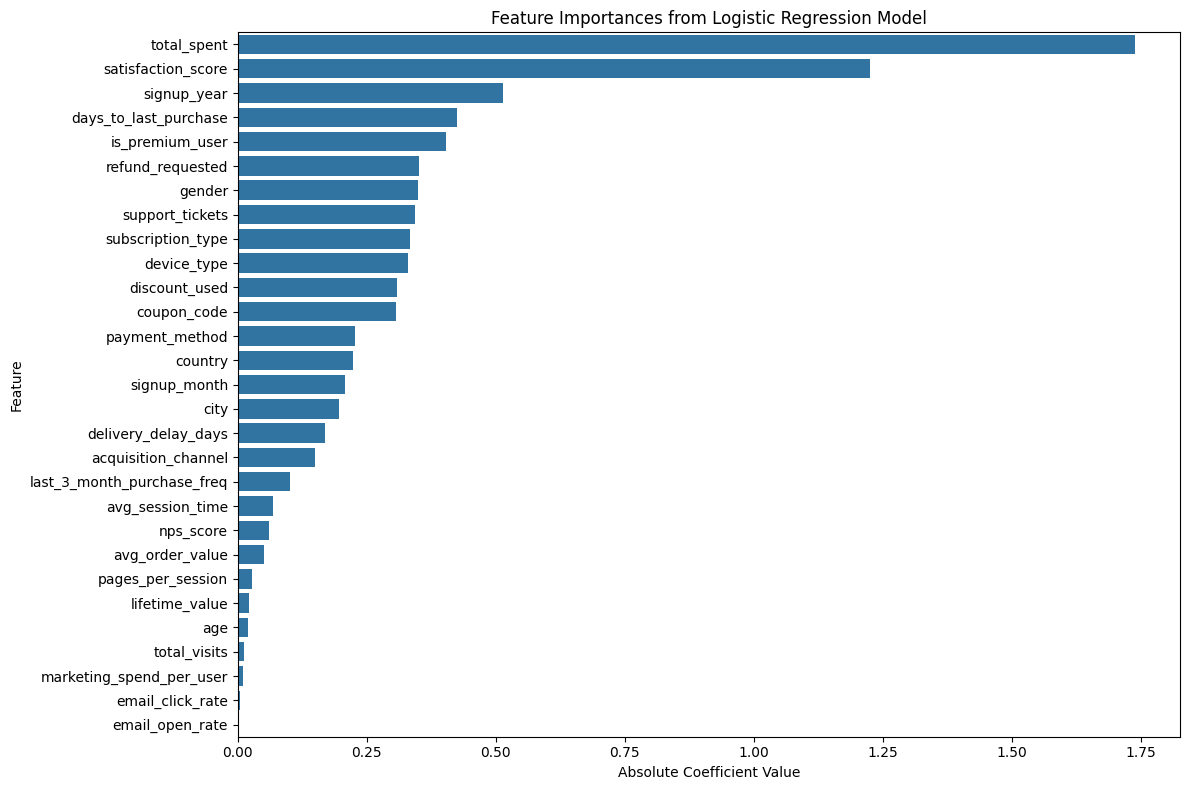

In [24]:
logistic_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': abs(lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("Feature Importances from Logistic Regression:")
print(logistic_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=logistic_importances)
plt.title('Feature Importances from Logistic Regression Model')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Importances from Random Forest:
                       Feature  Importance
21          satisfaction_score    0.267324
13                 total_spent    0.237671
17             support_tickets    0.047946
5                  device_type    0.025727
7              is_premium_user    0.023855
24              lifetime_value    0.021895
23    marketing_spend_per_user    0.021806
12            email_click_rate    0.021226
16                 coupon_code    0.020966
11             email_open_rate    0.020685
9             avg_session_time    0.020510
14             avg_order_value    0.020145
26       days_to_last_purchase    0.020135
10           pages_per_session    0.019305
20              payment_method    0.018424
1                          age    0.018309
2                      country    0.017612
3                         city    0.016950
15               discount_used    0.015678
25  last_3_month_purchase_freq    0.015441
4          acquisition_channel    0.015168
22            

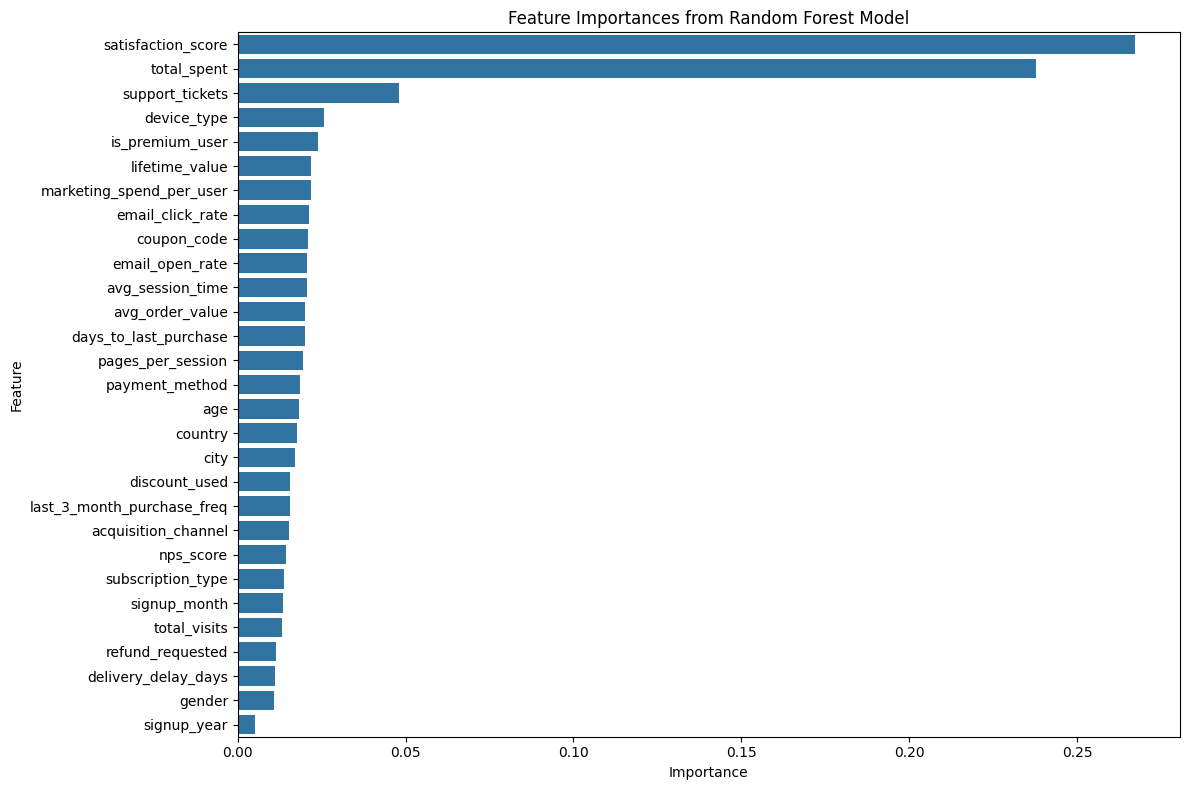

In [25]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

rf_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

print("Feature Importances from Random Forest:")
print(rf_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importances)
plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Importances from Ensemble Voting Model (Averaged Normalized):
                       Feature  Importance
21          satisfaction_score    0.216300
13                 total_spent    0.211830
17             support_tickets    0.066455
7              is_premium_user    0.040170
18            refund_requested    0.037974
5                  device_type    0.034660
6            subscription_type    0.029671
26       days_to_last_purchase    0.027596
15               discount_used    0.027400
16                 coupon_code    0.026949
27                 signup_year    0.026164
0                       gender    0.024509
20              payment_method    0.020956
2                      country    0.019913
3                         city    0.019227
4          acquisition_channel    0.016728
28                signup_month    0.016101
19         delivery_delay_days    0.013912
9             avg_session_time    0.013310
25  last_3_month_purchase_freq    0.012901
14             avg_order_va

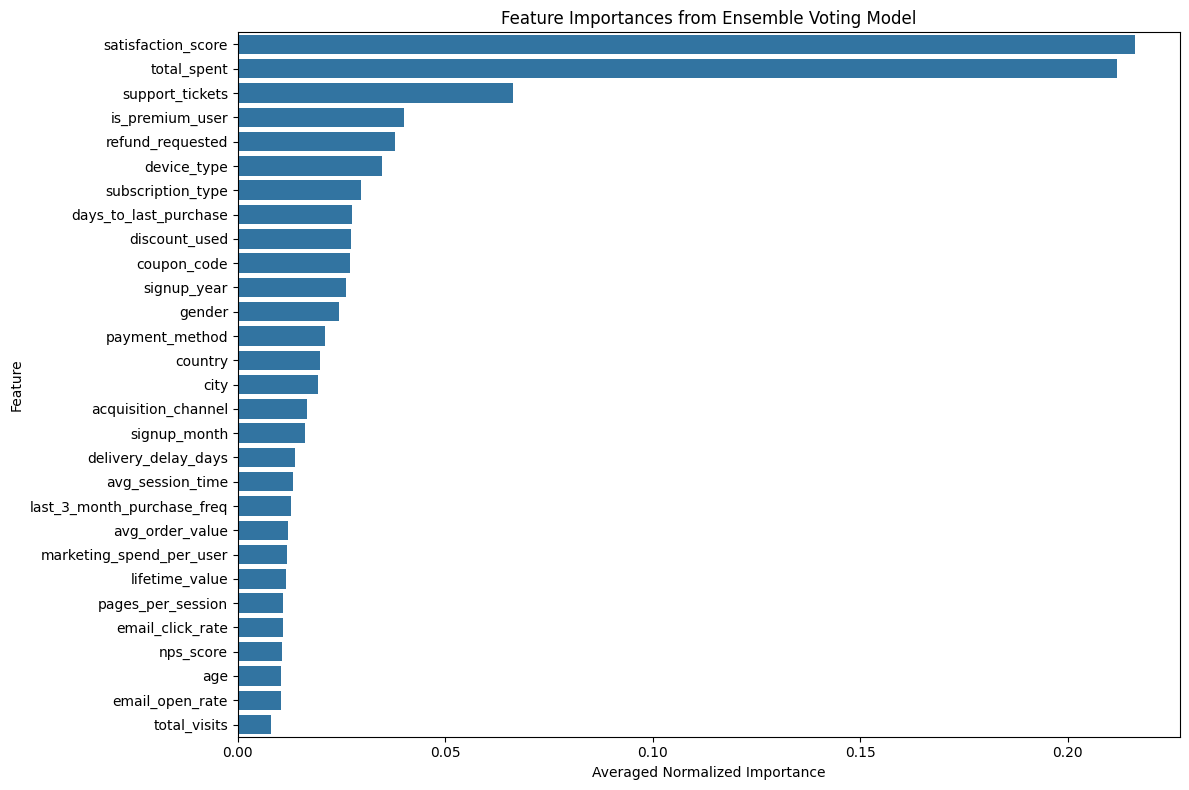

In [26]:
feature_names = X_train.columns

lr_importances_raw = abs(voting_model.estimators_[0].coef_[0])
rf_importances_raw = voting_model.estimators_[1].feature_importances_
xgb_importances_raw = voting_model.estimators_[2].feature_importances_

lr_importances_norm = lr_importances_raw / lr_importances_raw.sum()
rf_importances_norm = rf_importances_raw / rf_importances_raw.sum()
xgb_importances_norm = xgb_importances_raw / xgb_importances_raw.sum()

df_lr_imp = pd.DataFrame({'Feature': feature_names, 'Importance': lr_importances_norm})
df_rf_imp = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances_norm})
df_xgb_imp = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances_norm})

combined_importances = df_rf_imp.set_index('Feature')
combined_importances['Importance'] += df_lr_imp.set_index('Feature')['Importance']
combined_importances['Importance'] += df_xgb_imp.set_index('Feature')['Importance']

combined_importances['Importance'] /= 3 
combined_importances = combined_importances.reset_index().sort_values(by='Importance', ascending=False)

print("Feature Importances from Ensemble Voting Model (Averaged Normalized):")
print(combined_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=combined_importances)
plt.title('Feature Importances from Ensemble Voting Model')
plt.xlabel('Averaged Normalized Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()